# Credit Card Fraud Detection -- Exploratory Data Analysis (EDA)

*Authorship* -> *Héctor Ayuso Martín*

## 1. Project context

This notebook presents an exploratory data analysis of a credit card fraud detection dataset.
  
The main goal of this analysis is to understand the structure, quality, and distribution of the data before building a machine learning model. 

## 2. Dataset description

Credit card fraud detection is a common binary classification problem in machine learning. The objective is to identify potentially fraudulent transactions based on historical transaction patterns.

In this project, the exploratory analysis is performed before model training in order to avoid blindly applying algorithms without first understanding the dataset.

## 3. Imports and configuration

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format","{:.4f}".format)

## 4. Loading the dataset

In [6]:
DATA_PATH = Path("../data/raw/creditcard_2023.csv")

In [7]:
df = pd.read_csv(DATA_PATH)

In [8]:
df.head(2)

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.2606,-0.4696,2.4963,-0.0837,0.1297,0.7329,0.5190,-0.1300,0.7272,0.6377,-0.9870,0.2934,-0.9414,0.5490,1.8049,0.2156,0.5123,0.3336,0.1243,0.0912,-0.1106,0.2176,-0.1348,0.1660,0.1263,-0.4348,-0.0812,-0.1510,17982.1000,0
1,1,0.9851,-0.3560,0.5581,-0.4297,0.2771,0.4286,0.4065,-0.1331,0.3475,0.5298,0.1401,1.5642,0.5741,0.6277,0.7061,0.7892,0.4038,0.2018,-0.3407,-0.2340,-0.1949,-0.6058,0.0795,-0.5774,0.1901,0.2965,-0.2481,-0.0645,6531.3700,0


## 5. Initial inspection

The next step is to perform a first structural inspection of the dataset (dimensions, columns names, data type, pressence of missing values...)

In [10]:
df.shape

(568630, 31)

In [13]:
columns = df.columns.tolist()
print(columns)

['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,568630.0000,284314.5000,164149.4861,0.0000,142157.2500,284314.5000,426471.7500,568629.0000
V1,568630.0000,-0.0000,1.0000,-3.4956,-0.5653,-0.0936,0.8327,2.2290
V2,568630.0000,-0.0000,1.0000,-49.9666,-0.4867,-0.1359,0.3436,4.3619
V3,568630.0000,0.0000,1.0000,-3.1838,-0.6493,0.0004,0.6285,14.1258
V4,568630.0000,0.0000,1.0000,-4.9512,-0.6560,-0.0738,0.7070,3.2015
V5,568630.0000,0.0000,1.0000,-9.9528,-0.2935,0.0811,0.4397,42.7169
V6,568630.0000,0.0000,1.0000,-21.1111,-0.4459,0.0787,0.4978,26.1684
V7,568630.0000,0.0000,1.0000,-4.3518,-0.2835,0.2334,0.5260,217.8730
V8,568630.0000,0.0000,1.0000,-10.7563,-0.1923,-0.1145,0.0473,5.9580
V9,568630.0000,0.0000,1.0000,-3.7519,-0.5687,0.0925,0.5593,20.2701


### Abstract

The dataset contains *568330 rows and 31 columns*. This is a **solid volume** of data por ML.

The features are composed for (source -> Kaggle) :
- **@id** : Unique identifier for each transaction.
- **@v1** to **@v28** : Anonymized features representing various transaction attributes (e.g., time, location, etc.)
- **@Amount** : The transaction amount
- **@Class** : Binary label indicating whether the transaction is fraudulent (1) or not (0). Future target.

All features are numerical data, except the target (binary).

This dataset appears clean, numerical, model-ready, like preprocessed or engineered.

Rea-world fraud detection systems usually face severe class imbalance, and noisier raw transactional data.




## 6. Missing values and duplicates

In [16]:
missing_values = df.isnull().sum()

In [18]:
missing_values.sum()

np.int64(0)

No missing values, the workflow becomes simpler and more realiable.

In [19]:
duplicates_rows = df.duplicated().sum()

In [20]:
duplicates_rows

np.int64(0)

No missing values or duplicate values in the dataset. This is a strong adventage because the dataset can move directly to modeling satges, without additional work for cleaning data.

## 7. Target variable analysis

In [24]:
target_summary = pd.DataFrame({
    "Count" : df["Class"].value_counts(),
    "Percentage" : df["Class"].value_counts(normalize=True) * 100
})

In [25]:
target_summary

,Count,Percentage
Class,,
0,284315,50.0000
1,284315,50.0000


The dataset is balanced.

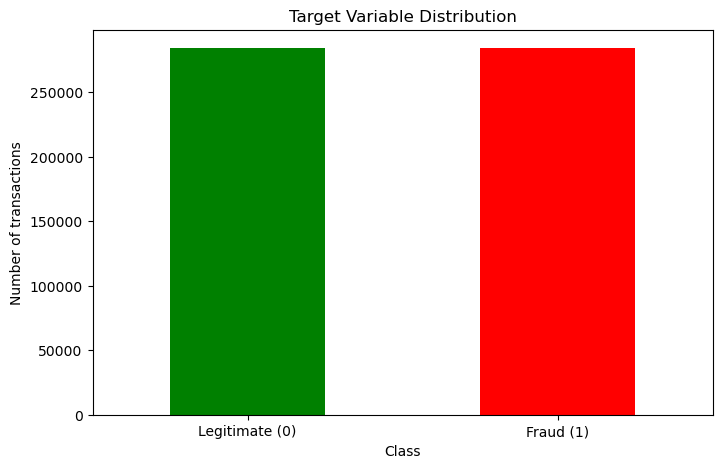

In [33]:
df["Class"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5),
    title="Target Variable Distribution",
    color=["green","red"]
)

plt.xticks([0,1],["Legitimate (0)", "Fraud (1)"], rotation=0)
plt.ylabel("Number of transactions")
plt.show()

A balanced dataset is useful for learning and experimentation because training is easier and baseline models are more stable.

This dataset is well suited for educational machine learning and portfolio development, but should not be interpreted as a raw real-world fraud stream.


## 8. Feature distributions

In [39]:
features = df.drop(columns=["Class"])

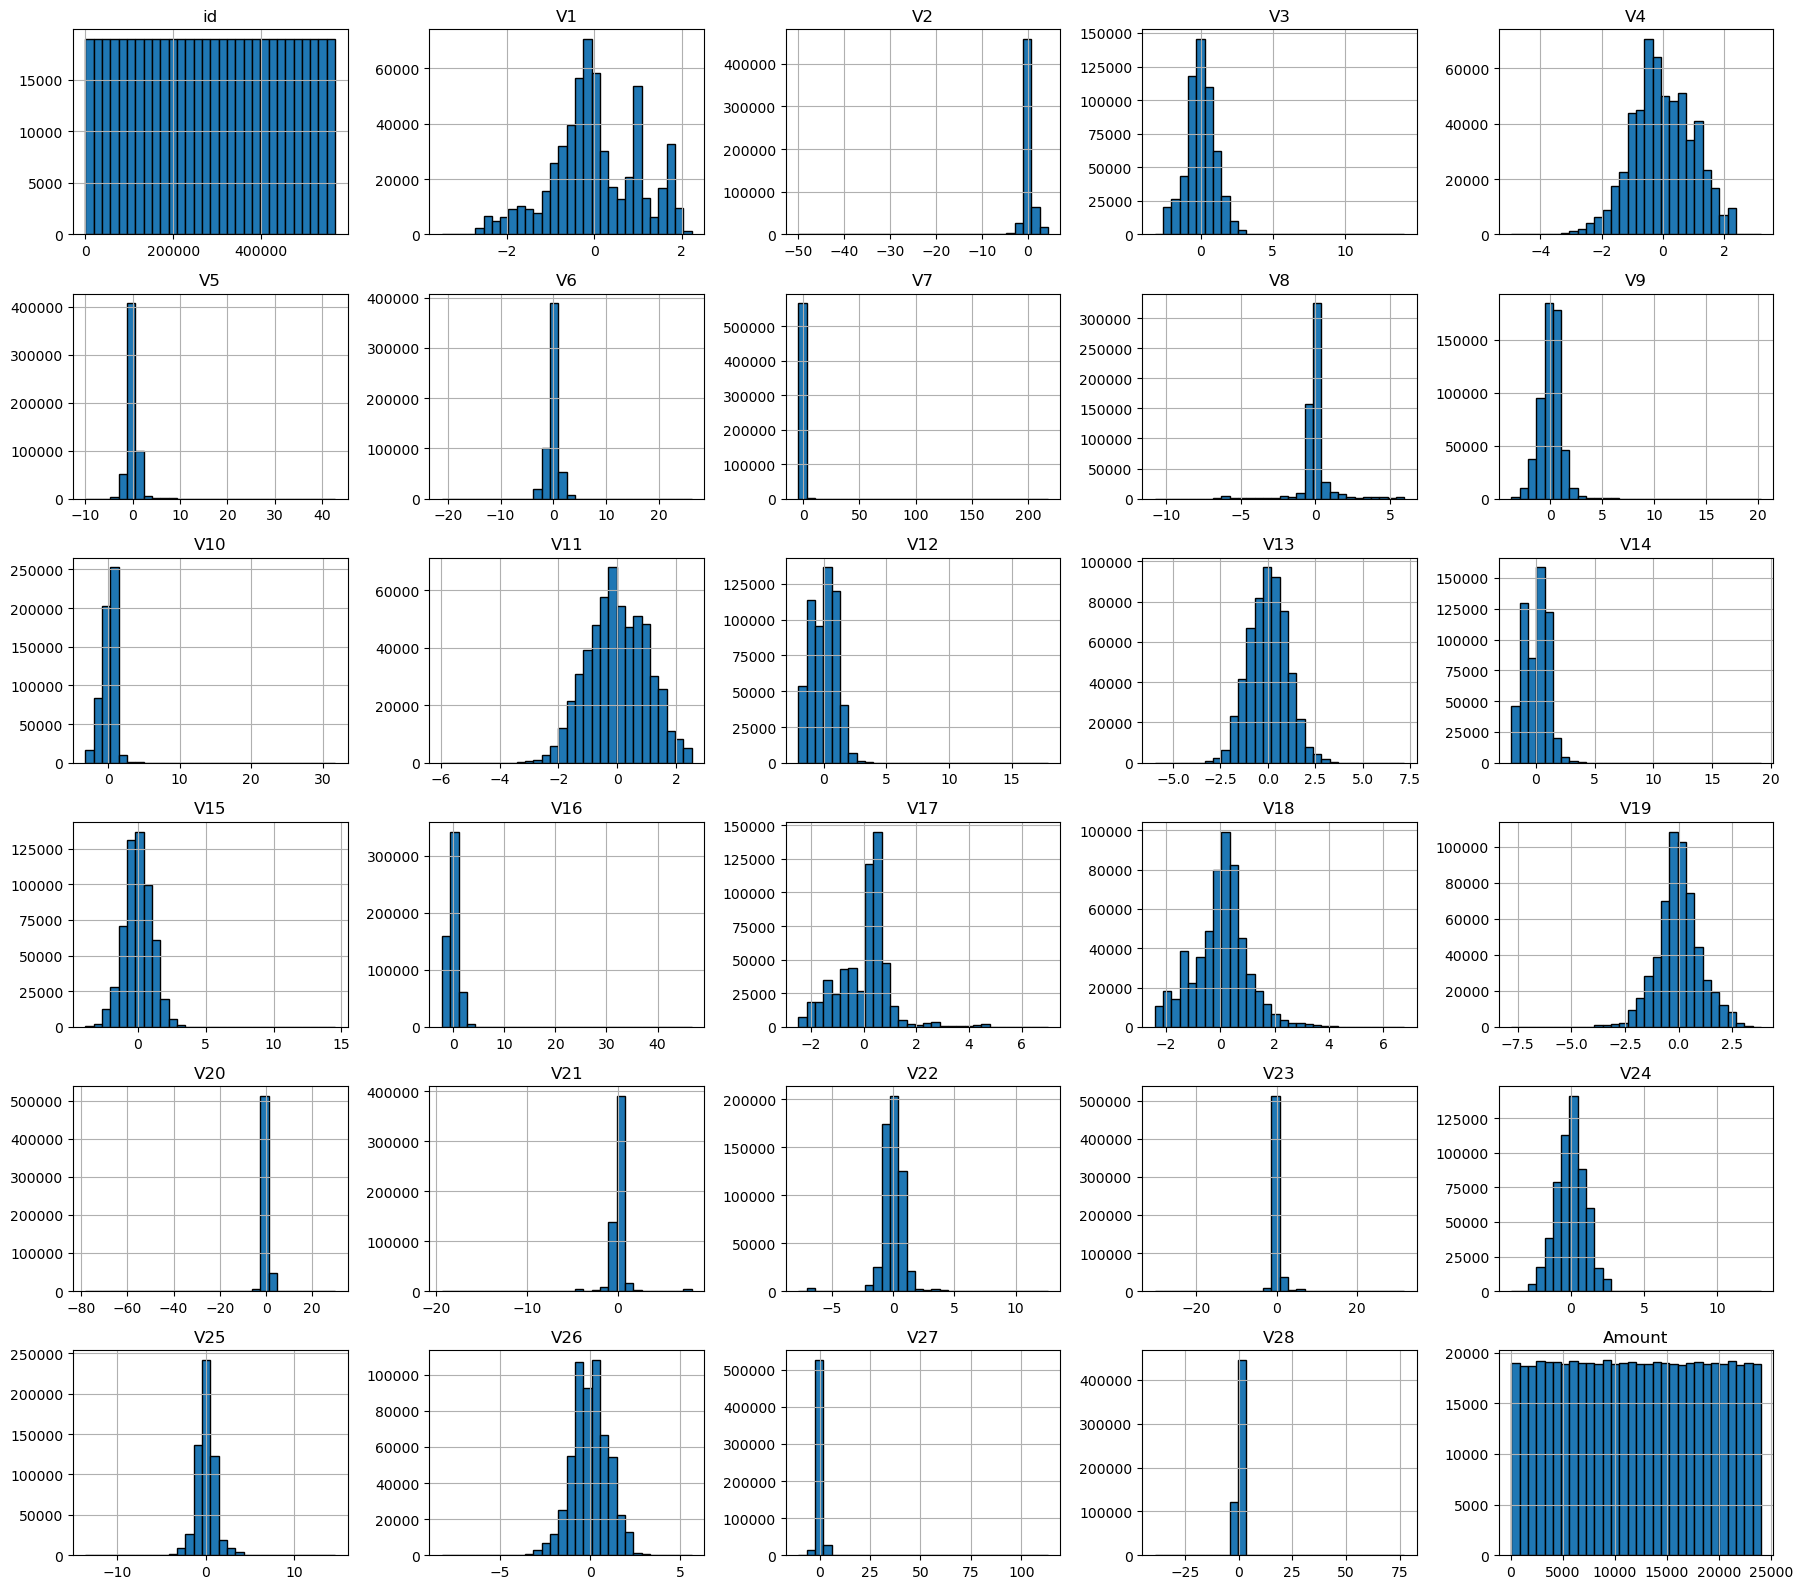

In [41]:
#Histograms:

features.hist(
    figsize=(18,16),
    bins=30,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

The variables from V1 to V28 are centered around zero and many of them show aprproximately simemtric distribution. This suggest that the original transactional variables were transformed or standardized before publication, likely for privacy protection or modeling convenience.

Some variables exhibit extreme tails or isolated hight magnitude values, like V7, V20, V23, V27 and v28. This suggest the presence of outliers.

As a summary, we observe that:
- The @id column should likely be removed before training.
- Tree-based models may handle outliers effectively.
- The dataset appears clean and highty model-ready.

## 9. Correlation analysis

In [42]:
#Correlation matrix
corr_matrix = df.corr()

In [48]:
#Correlaton with target variable
target_corr = corr_matrix["Class"].drop("Class").sort_values(ascending=False)

In [47]:
target_corr

id        0.8643
V4        0.7360
V11       0.7243
V2        0.4919
V19       0.2441
V27       0.2140
V20       0.1799
V8        0.1443
V21       0.1096
V28       0.1020
V26       0.0711
V25       0.0618
V22       0.0141
V23       0.0103
Amount    0.0023
V15      -0.0379
V13      -0.0711
V24      -0.1301
V5       -0.3386
V18      -0.4101
V6       -0.4351
V17      -0.4764
V7       -0.4912
V1       -0.5058
V16      -0.5735
V9       -0.5855
V10      -0.6737
V3       -0.6821
V12      -0.7686
V14      -0.8057
Name: Class, dtype: float64

Features with stronger correalation to the target @Class may contain predictive signal.

In [52]:
#Top positive and negative correlations with target
top_corr = pd.concat([
    target_corr.head(4),
    target_corr.tail(4)
])

In [55]:
top_corr

id     0.8643
V4     0.7360
V11    0.7243
V2     0.4919
V10   -0.6737
V3    -0.6821
V12   -0.7686
V14   -0.8057
Name: Class, dtype: float64

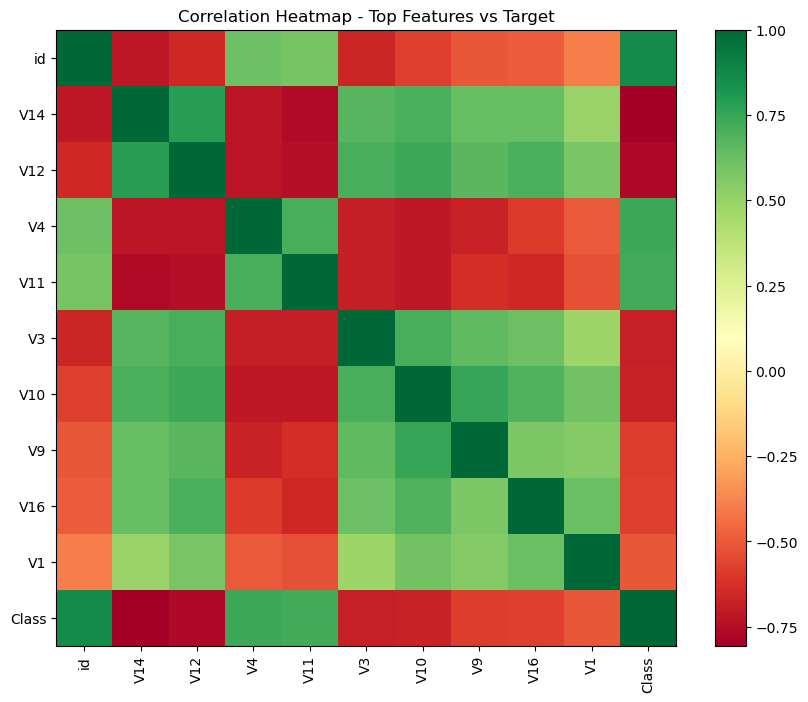

In [54]:
top_features = target_corr.abs().sort_values(ascending=False).head(10).index.tolist()
selected_cols = top_features + ["Class"]

plt.figure(figsize=(10,8))

plt.imshow(df[selected_cols].corr(), cmap="RdYlGn", aspect="auto")
plt.colorbar()

plt.xticks(range(len(selected_cols)), selected_cols, rotation=90)
plt.yticks(range(len(selected_cols)), selected_cols)

plt.title("Correlation Heatmap - Top Features vs Target")
plt.show()

Based on this analysis information: @id should be excluded from features. Variables such as @V14, @V12, @V4, @v11 and @V10 may be highty informative.

The dataset contains clear statistical signal for fraud classification. This suggest strong baseline model performance may be achievable.

## 10. Key EDA conclusions

### 1. Clean and Structured Dataset

The dataset is in very good technical condition:

- no missing values
- no duplicated rows
- numerical features only
- large sample size

This significantly reduces preprocessing complexity.

### 2. Balanced Target Variable

The target variable is perfectly balanced:

- 50% legitimate transactions
- 50% fraudulent transactions

This is useful for educational machine learning, although less representative of real production fraud systems.

### 3. Anonymous Preprocessed Features

Most variables appear standardized and anonymized.

This likely protects sensitive financial information while preserving predictive structure.

### 4. Presence of Predictive Signal

Several variables show clear correlation with the target, especially:

- `V14`
- `V12`
- `V4`
- `V11`

This suggests that the dataset is suitable for classification modeling.

### 5. Identifier Column Should Be Removed

The `id` column is sequential and should not be used during training.

It may create artificial patterns or leakage.

### 6. Outliers Are Present

Some variables contain extreme values.

This may affect linear models but is usually manageable for tree-based algorithms.

*Autorship : Héctor Ayuso Martín*